# F1A Benchmark - CPU vs GPU Performance

This notebook benchmarks the computational performance of FastBEMT aeroacoustic simulations on CPU and GPU devices across different problem scales.

In [1]:
import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller

## Load Propeller Geometry

In [3]:
with open('../Datasets/Propellers/10x7E.pkl', 'rb') as f:
    blade_dict = pickle.load(f)

## Define Performance Test Function

This function runs the benchmark across different time step scales for both CPU and GPU.

In [4]:
def run_performance_test(scales: list[int], r_observer: np.ndarray) -> tuple[list[float], list[float]]:
    cpu_results: list[float] = []
    gpu_results: list[float] = []

    for size in scales:
        print(f'Testing scale: {size} time steps...')

        revolutions = max(1, size // 100)

        # --- GPU BENCHMARK ---
        if torch.cuda.is_available():
            params_gpu = LowFidelityParameters(
                rpm=7000,
                a_inf=343,
                rho=1.225,
                mu=1.81e-5,
                n_blades=blade_dict['n_blades'],
                p_ref=2e-5,
                revolutions=revolutions,
                num_obs_times_per_rev=100,
                device='cuda',
            )
            propeller_gpu = Propeller(
                geometry=blade_dict,
                params=params_gpu,
                use_cuda_timing=False,
            )
            propeller_gpu.run_bemt(v_inf=0)

            # Warm-up
            propeller_gpu.run_aeroacoustics(observer_positions=r_observer)
            torch.cuda.synchronize()

            start_gpu = torch.cuda.Event(enable_timing=True)
            end_gpu = torch.cuda.Event(enable_timing=True)
            start_gpu.record()
            propeller_gpu.run_aeroacoustics(observer_positions=r_observer)
            end_gpu.record()
            torch.cuda.synchronize()
            gpu_results.append(start_gpu.elapsed_time(end_gpu))
        else:
            gpu_results.append(float('nan'))

        # --- CPU BENCHMARK ---
        params_cpu = LowFidelityParameters(
            rpm=7000,
            a_inf=343,
            rho=1.225,
            mu=1.81e-5,
            n_blades=blade_dict['n_blades'],
            p_ref=2e-5,
            revolutions=revolutions,
            num_obs_times_per_rev=100,
            device='cpu',
        )
        propeller_cpu = Propeller(
            geometry=blade_dict,
            params=params_cpu,
            use_cuda_timing=False,
        )
        propeller_cpu.run_bemt(v_inf=0)

        # Warm-up
        propeller_cpu.run_aeroacoustics(observer_positions=r_observer)

        start_cpu = time.perf_counter()
        propeller_cpu.run_aeroacoustics(observer_positions=r_observer)
        end_cpu = time.perf_counter()
        cpu_results.append((end_cpu - start_cpu) * 1000.0)

    return cpu_results, gpu_results

## Run Benchmark

Execute the performance test across different problem scales.

In [5]:
observer_positions = np.array([[0.0, 1.88, 0.0]])
problem_scales = [100, 500, 1000, 5000, 10000, 50000]

cpu_times, gpu_times = run_performance_test(problem_scales, observer_positions)

Testing scale: 100 time steps...
Testing scale: 500 time steps...
Testing scale: 1000 time steps...
Testing scale: 5000 time steps...
Testing scale: 10000 time steps...
Testing scale: 50000 time steps...


## Plot Results

Visualize the performance comparison between CPU and GPU execution.

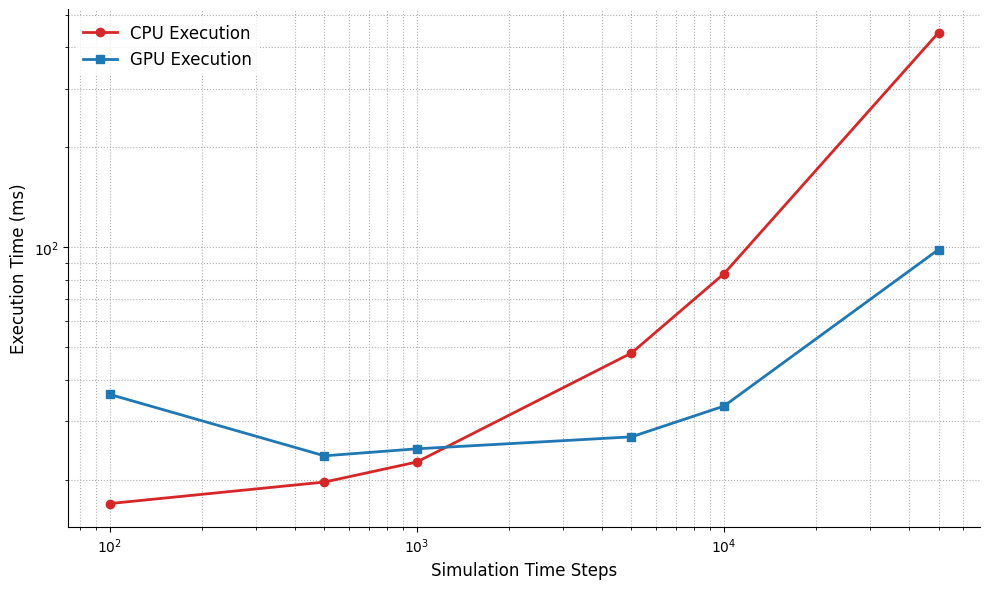

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    problem_scales,
    cpu_times,
    'o-',
    label='CPU Execution',
    color='tab:red',
    linewidth=2,
)
ax.plot(
    problem_scales,
    gpu_times,
    's-',
    label='GPU Execution',
    color='tab:blue',
    linewidth=2,
)

ax.set_xlabel('Simulation Time Steps', fontsize=12)
ax.set_ylabel('Execution Time (ms)', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle=':', alpha=1.0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.legend(frameon=True, edgecolor='none', fontsize=12)

plt.tight_layout()
plt.savefig('../Figures/F1A_Benchmark.pdf', dpi=200)
plt.show()